In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [6]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [7]:
train['geohash'].unique()
train.sample(10)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
42018,42018,qp09uv,48,11:45,0.559451,Highway,3,Allowed,Yes,21.688229,Sunny
50899,50899,qp09sd,48,14:30,0.159737,Residential,1,Not Allowed,No,18.854677,Foggy
16117,16117,qp0d0j,48,4:30,0.029389,Residential,3,Allowed,Yes,23.323344,Sunny
54768,54768,qp096x,48,16:0,0.639274,Highway,3,Allowed,Yes,18.394586,Foggy
16109,16109,qp0djh,48,4:30,0.037890,Residential,2,Not Allowed,Yes,23.756650,Sunny
39306,39306,qp03zs,48,11:0,0.024316,Residential,2,Not Allowed,Yes,23.214540,Sunny
60684,60684,qp03tx,48,19:45,0.006488,Residential,3,Allowed,Yes,12.405076,Rainy
73145,73145,qp09kv,49,1:0,0.347579,Street,1,Not Allowed,Yes,5.331197,Snowy
22951,22951,qp0982,48,6:30,0.150390,Residential,1,Not Allowed,No,1.526243,Snowy
43058,43058,qp02z9,48,12:15,0.056575,Residential,2,Not Allowed,Yes,15.625535,Foggy


In [8]:
train['day'].unique()


array([48, 49], dtype=int64)

In [9]:
print(train['RoadType'].unique())
print(train['NumberofLanes'].unique())
print(train['Weather'].unique())


[nan 'Residential' 'Street' 'Highway']
[1 3 2 4 5]
[nan 'Sunny' 'Rainy' 'Foggy' 'Snowy']


In [10]:

print(train.shape)
print(train.info())
print(train.isnull().sum())
missing_percent = (train.isnull().sum()/len(train))*100
print(missing_percent.sort_values(ascending=False))

(77299, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB
None
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           79

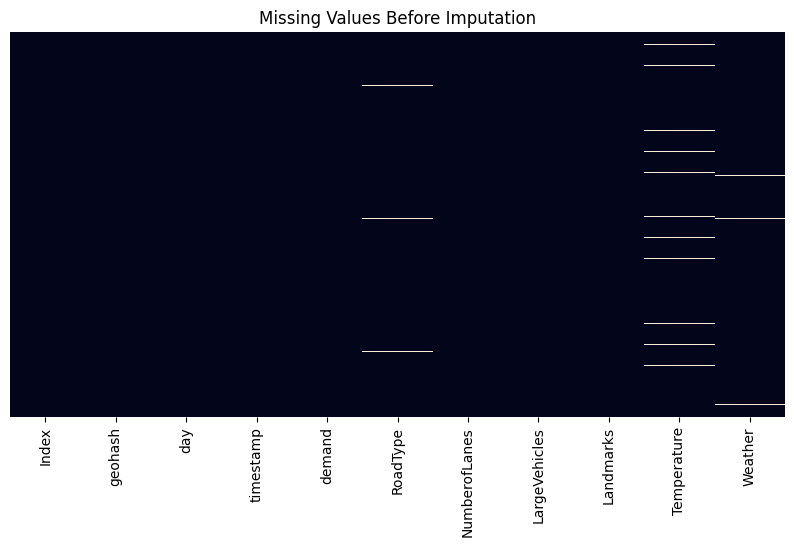

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    train.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Before Imputation")
plt.show()


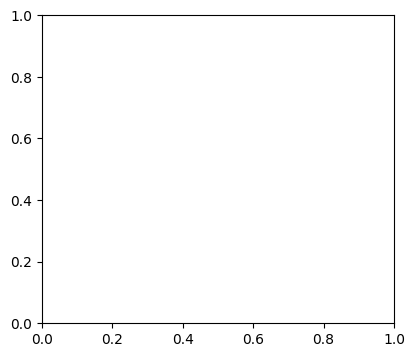

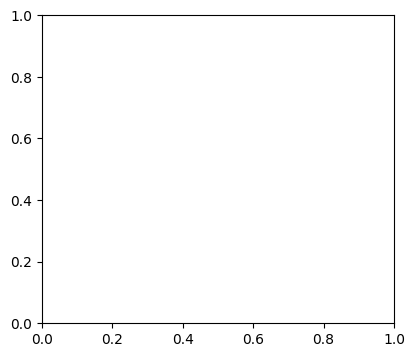

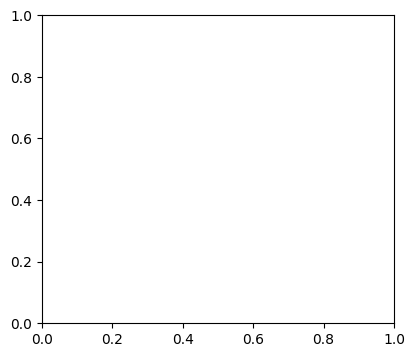

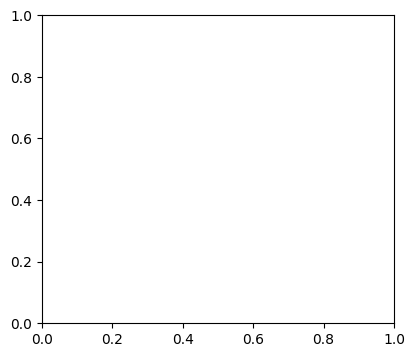

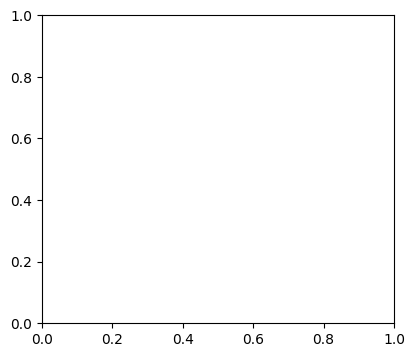

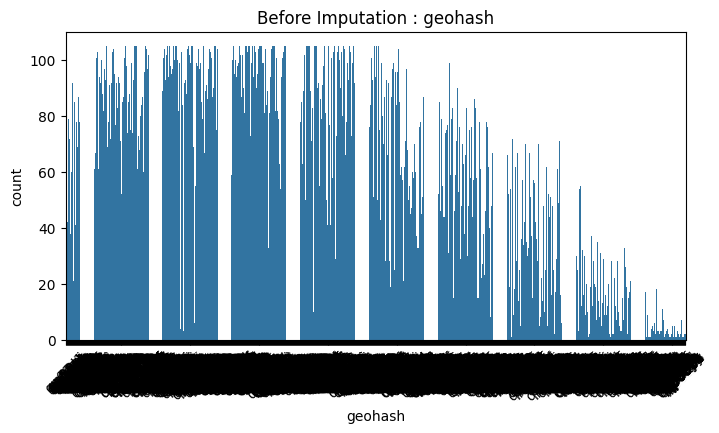

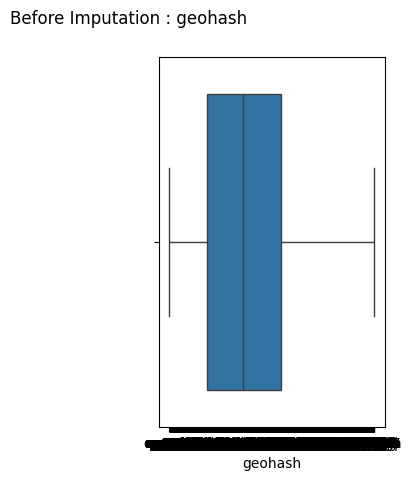

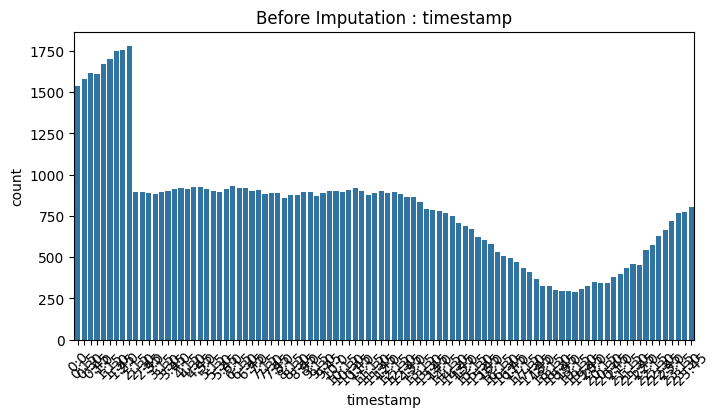

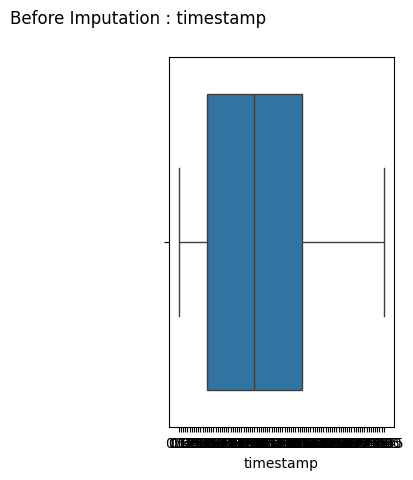

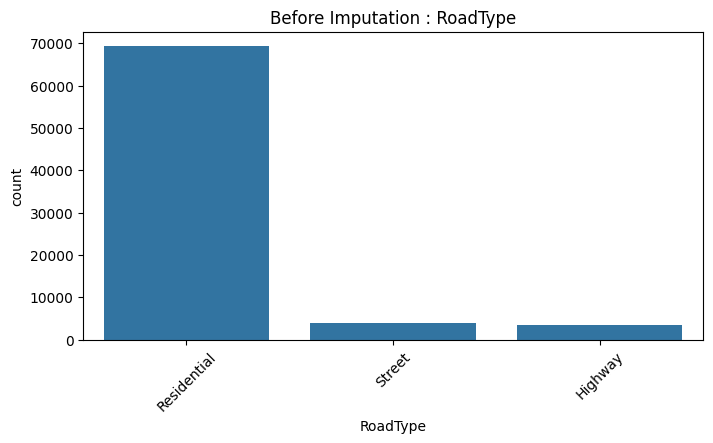

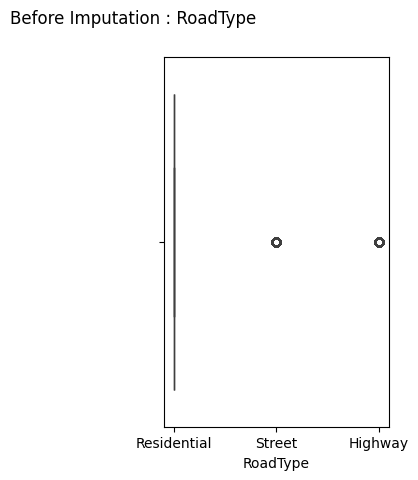

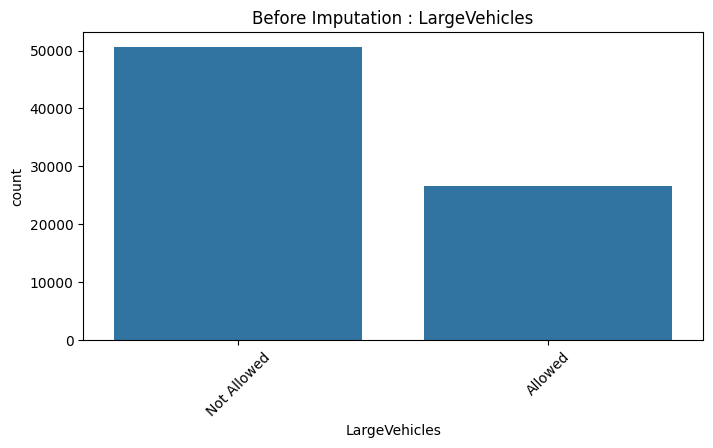

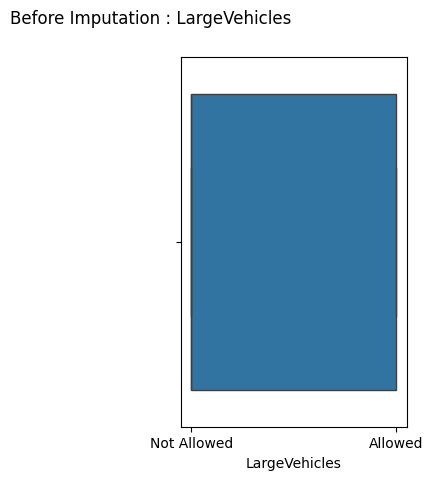

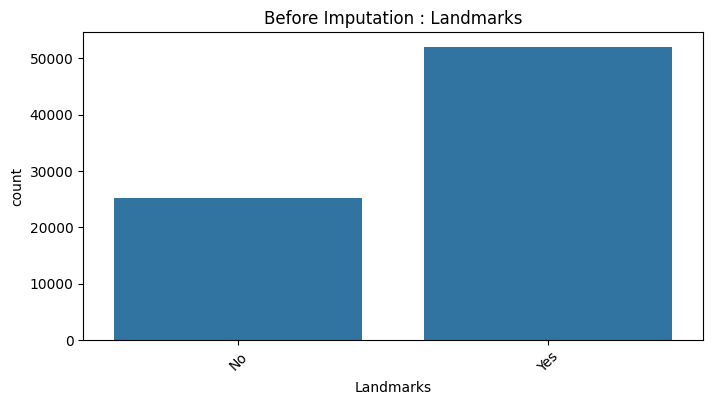

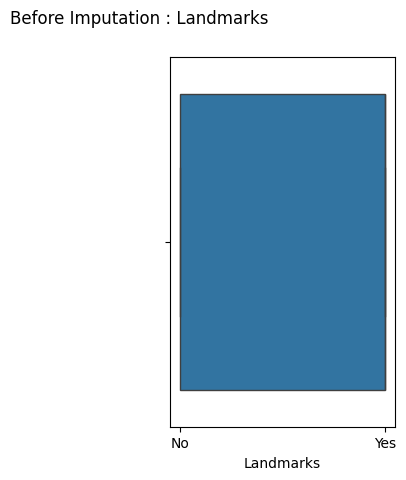

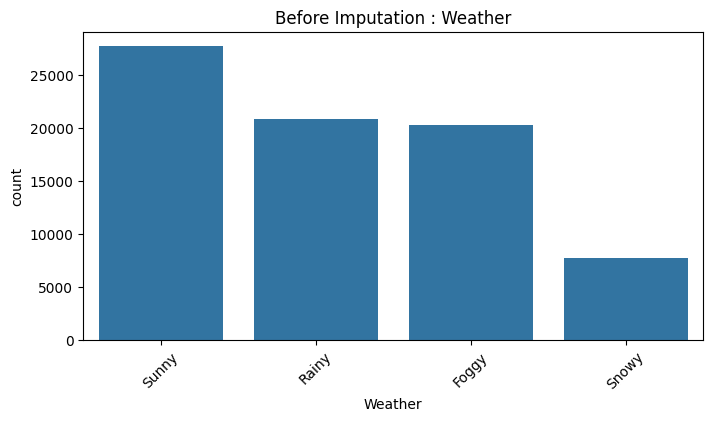

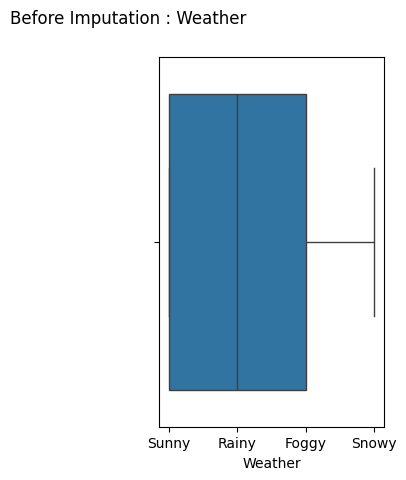

In [12]:
num_cols = train.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
        
            plt.figure(figsize=(8,4))
        
            sns.countplot(
                data=train,
                x=col
            )
        
            plt.xticks(rotation=45)
            plt.title(f"Before Imputation : {col}")
            plt.show()
        
            plt.subplot(1,2,2)
            sns.boxplot(x=train[col])
        
            plt.suptitle(f"Before Imputation : {col}")
            plt.show()

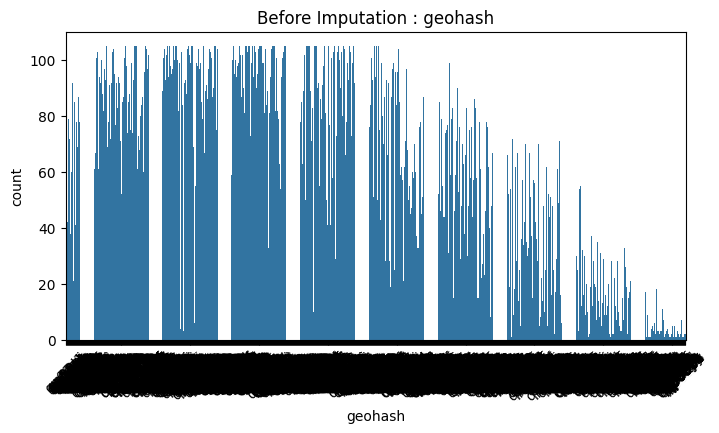

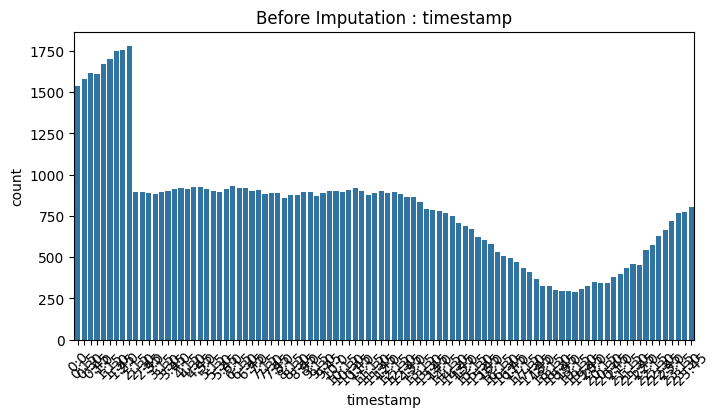

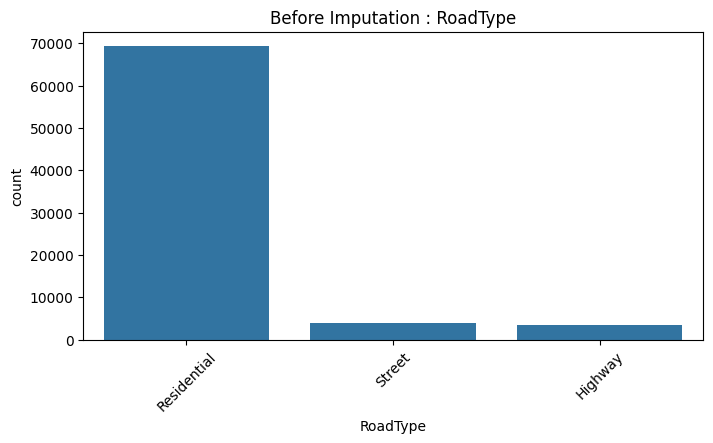

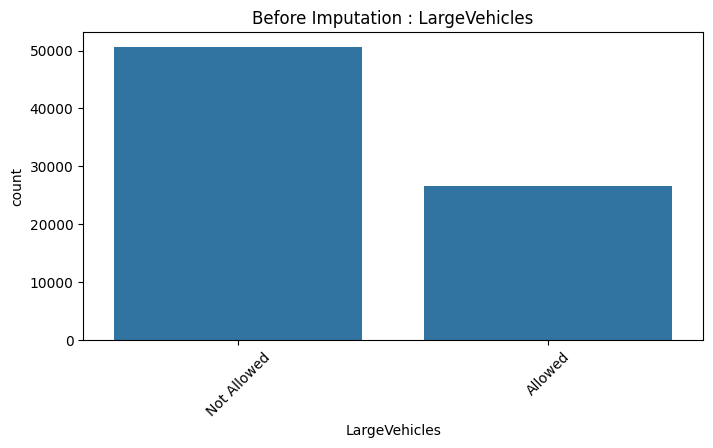

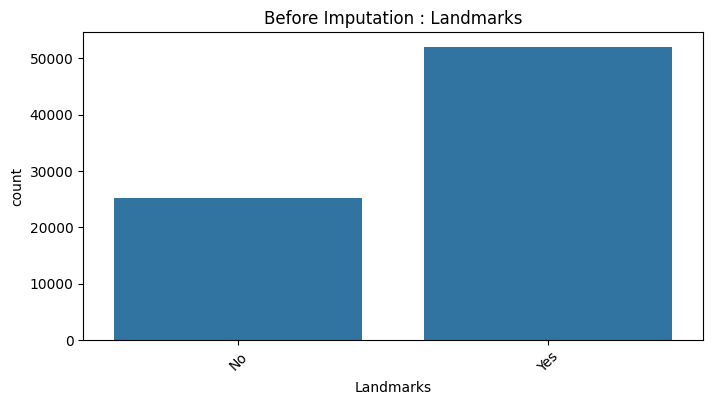

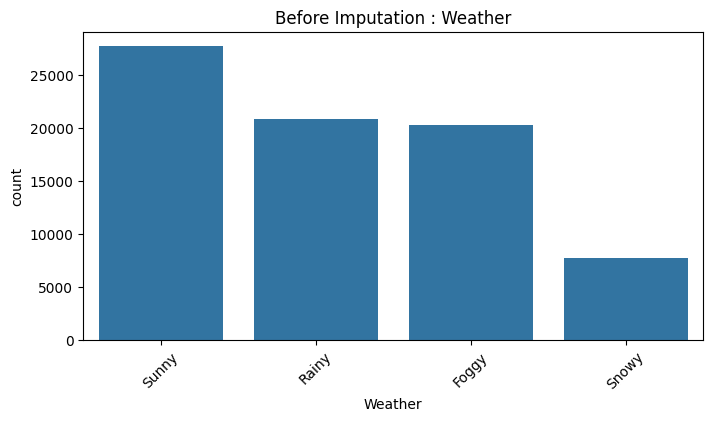

In [13]:
cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=train,
        x=col
    )

    plt.xticks(rotation=45)
    plt.title(f"Before Imputation : {col}")
    plt.show()

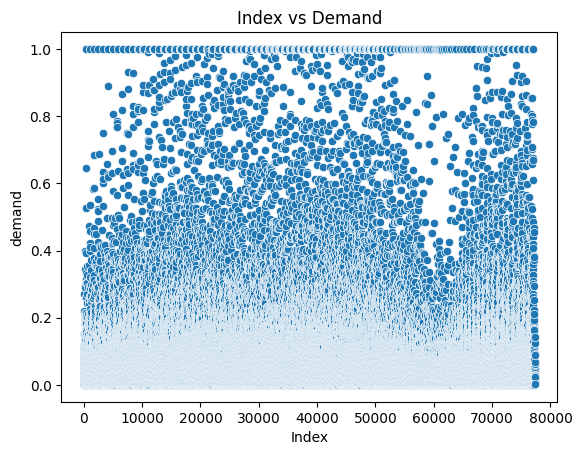

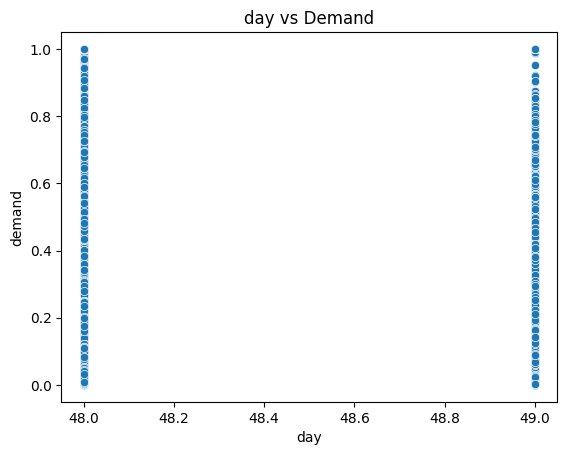

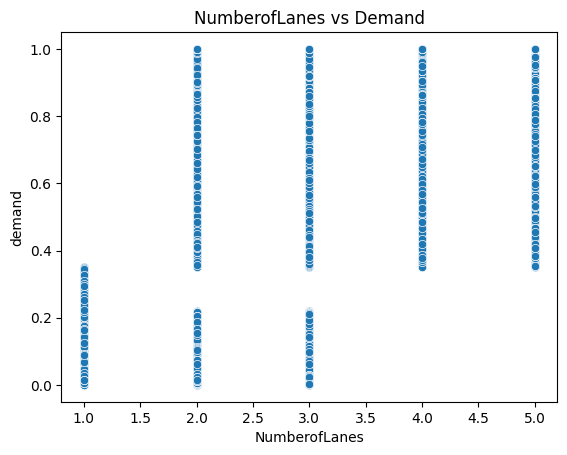

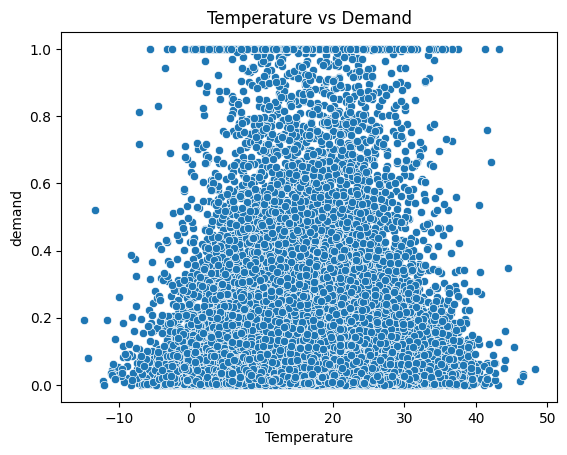

In [14]:
for col in num_cols:

    if col != "demand":

        sns.scatterplot(
            data=train,
            x=col,
            y="demand"
        )

        plt.title(f"{col} vs Demand")
        plt.show()

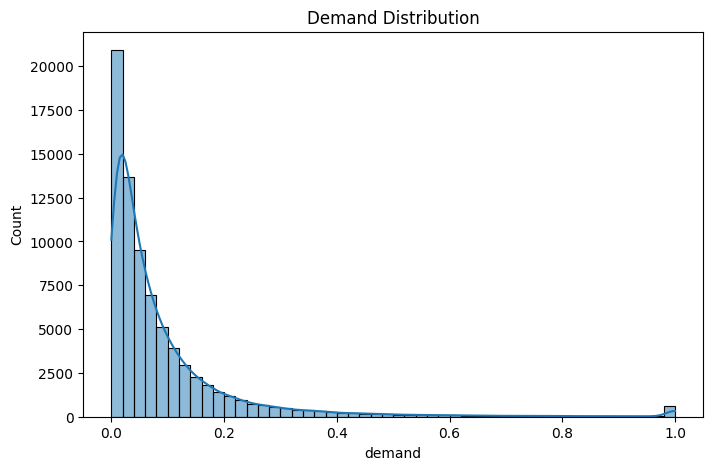

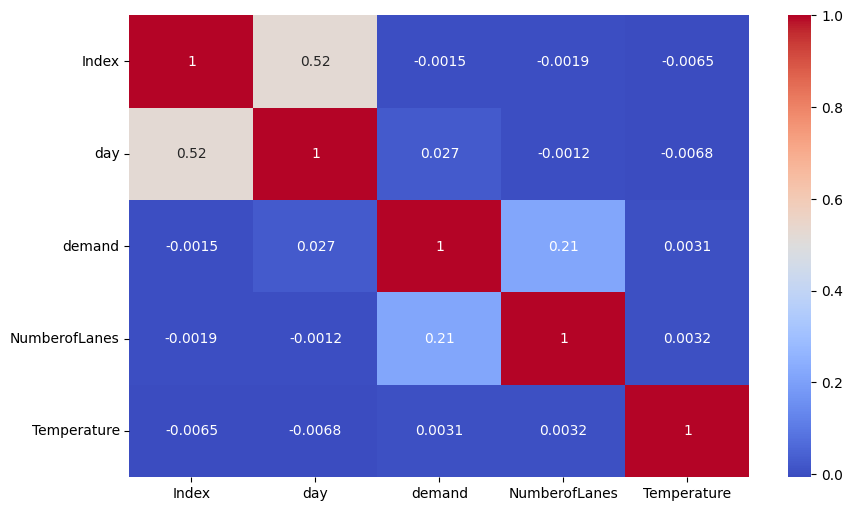

In [15]:
# Target Distribution

plt.figure(figsize=(8,5))
sns.histplot(train["demand"], bins=50, kde=True)
plt.title("Demand Distribution")
plt.show()

# Correlation
numeric_cols = train.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [16]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [17]:
train.sample(10)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
35964,35964,qp0959,48,10:15,0.038926,Residential,2,Not Allowed,Yes,8.471641,Rainy
46880,46880,qp093q,48,13:15,0.001518,Residential,2,Not Allowed,Yes,28.073108,Sunny
6460,6460,qp0963,48,2:0,0.082574,Residential,2,Not Allowed,Yes,25.949183,Sunny
10977,10977,qp096s,48,3:15,0.037891,Residential,2,Not Allowed,Yes,16.241015,Foggy
21248,21248,qp03xj,48,6:0,0.262896,Street,1,Not Allowed,Yes,32.591576,Sunny
44090,44090,qp091w,48,12:30,0.038177,Residential,2,Not Allowed,Yes,21.883782,Sunny
70848,70848,qp09g8,49,0:15,0.197431,Residential,2,Not Allowed,Yes,24.387801,Sunny
58465,58465,qp09d2,48,18:0,0.291417,Street,1,Not Allowed,Yes,27.440341,Sunny
35659,35659,qp09b5,48,10:0,0.113199,Residential,1,Not Allowed,No,13.660453,Rainy
66673,66673,qp098c,48,23:0,0.016931,Residential,2,Not Allowed,Yes,10.688109,Rainy


In [18]:

X = train.drop("demand", axis=1)
y = train["demand"]

In [19]:

categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns

In [20]:


numeric_transformer = Pipeline(
    steps=[
        ("imputer",
         SimpleImputer(strategy="median"))
    ]
)

In [21]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer",
         SimpleImputer(strategy="most_frequent")),
        ("encoder",
         OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         numeric_transformer,
         numerical_features),

        ("cat",
         categorical_transformer,
         categorical_features)
    ]
)

In [22]:
X.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [23]:

model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03
    ,    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

    
    

In [24]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [25]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_valid)

mae = mean_absolute_error(y_valid, preds)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
r2 = r2_score(y_valid, preds)

print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R2   : {r2}")

MAE  : 0.02932623660917426
RMSE : 0.0390573546142889
R2   : 0.9246100210939887


In [26]:

from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor()

pipeline2= Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model2)
    ]
)
pipeline2.fit(X_train, y_train)

preds = pipeline2.predict(X_valid)

mae = mean_absolute_error(y_valid, preds)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
r2 = r2_score(y_valid, preds)

print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R2   : {r2}")

MAE  : 0.025820158104284594
RMSE : 0.03936791767217736
R2   : 0.9234063334524409
